--- Generating Hindcasting Validation Chart: Observed vs 18 Scenarios ---


Success! Validation chart saved at: ..\figuras\figure-hindcasting-validation-en.pdf


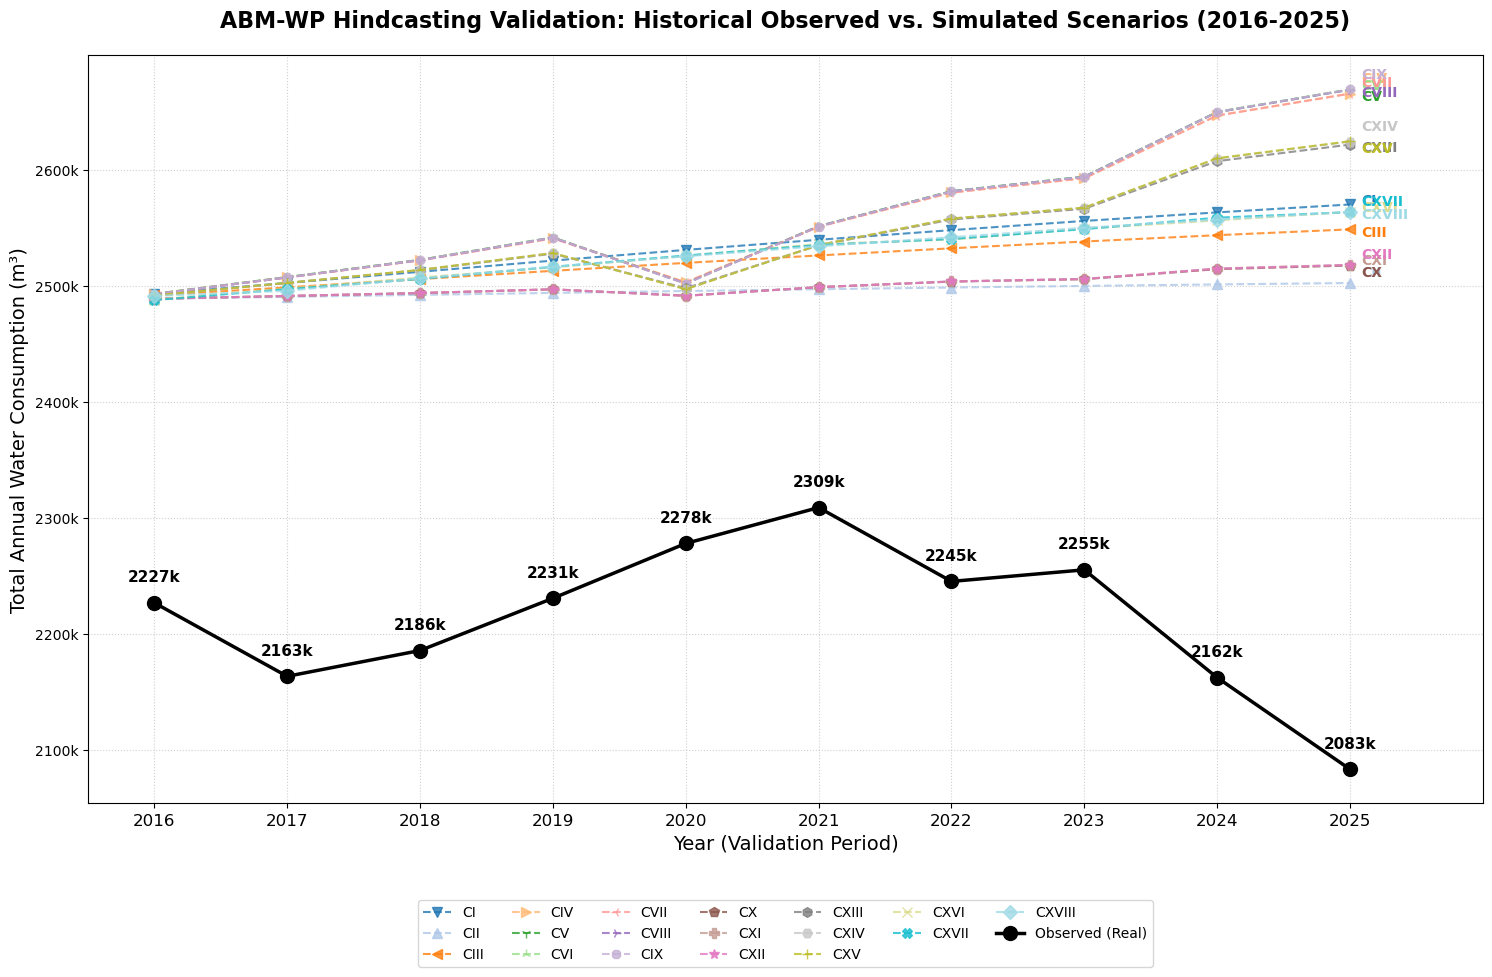

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import os

# ==========================================
# 1. Configurations and Paths
# ==========================================
# Base project directory
BASE_PATH = '..' 

# Input Filenames (Arquivos de Hindcasting)
REAL_FILE = 'Tabela_consumo_real_historico_2016_2025.csv'
SIM_FILE = 'simulacao_hindcasting_2016_2025.csv'

# Output Configuration
OUTPUT_DIR = os.path.join(BASE_PATH, 'figuras')
OUTPUT_FIG = 'figure-hindcasting-validation-en.pdf'

# Search Directories
INPUT_DIR_INCLUDES = os.path.join(BASE_PATH, 'includes')
INPUT_DIR_RESULTS = os.path.join(BASE_PATH, 'resultados')

def aggregate_annually(df, date_col, value_cols):
    """ Aggregates monthly data points into annual totals. """
    df_yearly = df.copy()
    df_yearly['Year'] = df_yearly[date_col].dt.year
    return df_yearly.groupby('Year')[value_cols].sum().reset_index()

def main():
    print("--- Generating Hindcasting Validation Chart: Observed vs 18 Scenarios ---")

    # ==========================================
    # 2. Data Loading and Preparation
    # ==========================================
    
    # A. Load Real Historical Data (Ground Truth)
    path_real = os.path.join(INPUT_DIR_INCLUDES, REAL_FILE)
    df_real = pd.read_csv(path_real, sep=';', decimal='.')
    # AM_REFERENCIA format: YYYYMM
    df_real['Date'] = pd.to_datetime(df_real['AM_REFERENCIA'].astype(str) + '01', format='%Y%m%d')
    df_real.rename(columns={'real_total_consumption': 'Real'}, inplace=True)

    # B. Load Simulation Hindcasting Results
    path_sim = os.path.join(INPUT_DIR_RESULTS, SIM_FILE)
    df_sim = pd.read_csv(path_sim, sep=';', decimal=',')
    
    if 'Ano' in df_sim.columns and 'Mes' in df_sim.columns:
        df_sim['Date'] = pd.to_datetime(df_sim['Ano'].astype(str) + '-' + df_sim['Mes'].astype(str) + '-01')
    
    # Identify scenario columns
    scenario_cols = [c for c in df_sim.columns if c not in ['Mes', 'Ano', 'Mes_Ano', 'Date', 'AM_REFERENCIA']]

    # Annual Aggregation
    df_real_sum = aggregate_annually(df_real, 'Date', ['Real'])
    df_sim_sum = aggregate_annually(df_sim, 'Date', scenario_cols)

    # ==========================================
    # 3. Plotting (Following the requested pattern)
    # ==========================================
    fig, ax = plt.subplots(figsize=(18, 11))

    # --- A. Plotting 18 Scenarios (Standardized Visibility) ---
    markers_list = ['v', '^', '<', '>', '1', '2', '3', '4', '8', 'p', 'P', '*', 'h', 'H', '+', 'x', 'X', 'D']
    colors = plt.cm.tab20(np.linspace(0, 1, len(scenario_cols)))
    label_offsets = [(8, 0), (8, 5), (8, -5), (8, 8), (8, -8)]
    
    for idx, col in enumerate(scenario_cols):
        scen_id = col.split('_')[0] # Pega "CI", "CII", etc.
        
        ax.plot(df_sim_sum['Year'], df_sim_sum[col], label=scen_id, color=colors[idx],
                linestyle='--', linewidth=1.5, alpha=0.8, 
                marker=markers_list[idx % len(markers_list)], markersize=7)
        
        # Position Scenario ID at the end of the line
        last_x = df_sim_sum['Year'].iloc[-1]
        last_y = df_sim_sum[col].iloc[-1]
        ax.annotate(scen_id, (last_x, last_y), xytext=label_offsets[idx % 5], 
                    textcoords="offset points", fontsize=10, color=colors[idx], fontweight='bold')

    # --- B. Plotting Historical Ground Truth (Highlighted) ---
    ax.plot(df_real_sum['Year'], df_real_sum['Real'], label='Observed (Real)', color='black',
            linestyle='-', linewidth=2.5, marker='o', markersize=10, zorder=20)

    # Historical values annotation (in 'k')
    for x, y in zip(df_real_sum['Year'], df_real_sum['Real']):
        ax.annotate(f"{y/1000:.0f}k", (x, y), xytext=(0, 15), textcoords="offset points",
                    ha='center', fontsize=11, fontweight='bold', color='black')

    # ==========================================
    # 4. Final Formatting and Export
    # ==========================================
    ax.set_ylabel('Total Annual Water Consumption (m³)', fontsize=14)
    ax.set_xlabel('Year (Validation Period)', fontsize=14)
    
    # Axis Tick Configuration
    full_timeline = df_real_sum['Year'].tolist()
    ax.set_xticks(full_timeline)
    ax.set_xticklabels(full_timeline, rotation=0, ha='center', fontsize=12)
    
    # Format Y-axis to 'k' (thousands) notation
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x/1000:.0f}k'))
    
    # Adjust Limits (Give space for labels)
    ax.set_xlim(full_timeline[0]-0.5, full_timeline[-1]+1.0)
    plt.grid(True, linestyle=':', alpha=0.6)

    # Title with Scientific Context
    plt.title('ABM-WP Hindcasting Validation: Historical Observed vs. Simulated Scenarios (2016-2025)', 
              fontsize=16, fontweight='bold', pad=20)

    # Legend Layout
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=7, 
               fontsize=11, frameon=True, prop={'weight': 'normal'})
    
    plt.subplots_adjust(bottom=0.20)

    # Save to PDF
    if not os.path.exists(OUTPUT_DIR): os.makedirs(OUTPUT_DIR)
    save_path = os.path.join(OUTPUT_DIR, OUTPUT_FIG)
    plt.savefig(save_path, format='pdf', bbox_inches='tight')
    
    print(f"Success! Validation chart saved at: {save_path}")
    plt.show()

if __name__ == "__main__":
    main()